# Assignment 2: Sanskrit-to-English Neural Machine Translation (NMT)

## Course
Natural Language Understanding (NLU)

---

## Student Details

| Field | Details |
|--------|---------|
| Student Name | <Your Name> |
| Roll Number | <Your Roll Number> |
| Assignment | Assignment 2 |
| Framework | PyTorch |
| Architecture | Seq2Seq (LSTM + Attention + Beam Search) |

---

## Objective

Develop a custom Neural Machine Translation (NMT) model to translate Sanskrit sentences into English using a Sequence-to-Sequence (Seq2Seq) architecture with:

- LSTM Encoder
- Attention-based Decoder
- Beam Search Decoding

Evaluate the model using:

- BLEU Score
- BERTScore
- Inference Time
- Total Trainable Parameters

---

## Notebook Structure

1. Installation & Imports
2. Configuration (all tuneable parameters)
3. Data Loading & Preprocessing
4. Vocabulary
5. Dataset & DataLoader
6. Model (Encoder · Attention · Decoder · Seq2Seq)
7. Training
8. Inference (Greedy + Beam Search)
9. Evaluation (BLEU · BERTScore · Efficiency)
10. Submission CSV
11. Translation Examples & Error Analysis

---

## 1. Installation & Imports
### Install Required Packages

In [57]:
# ==========================================================
# INSTALL REQUIRED PACKAGES
# ==========================================================

# Deep Learning Framework
%pip install -q torch torchvision torchaudio

# Data Processing
%pip install -q pandas numpy

# Visualization
%pip install matplotlib

# NLP Utilities
%pip install -q nltk

# Evaluation Metric
%pip install -q bert-score

# Tokenizer (Optional but recommended)
%pip install -q sentencepiece

# Progress Bar
%pip install -q tqdm

print("All required packages installed successfully.")

You should consider upgrading via the '/Users/krishnendu/.local/bin/python3.10 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/krishnendu/.local/bin/python3.10 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/krishnendu/.local/bin/python3.10 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/krishnendu/.local/bin/python3.10 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/krishnendu/.local/bin/python3.10 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/krishnendu/.local/bin/python3.10 -

### Import Libraries

In [58]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

# ----------------------------
# Standard Library
# ----------------------------
import os
import re
import time
import math
import random
import warnings
from collections import Counter

# ----------------------------
# Data Processing
# ----------------------------
import numpy as np
import pandas as pd

# ----------------------------
# Visualization
# ----------------------------
import matplotlib.pyplot as plt

# ----------------------------
# Progress Bar
# ----------------------------
from tqdm.auto import tqdm

# ----------------------------
# Deep Learning (PyTorch)
# ----------------------------
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

# ----------------------------
# Evaluation
# ----------------------------
import nltk
from nltk.translate.bleu_score import corpus_bleu
from bert_score import score as bert_score

# ----------------------------
# Tokenizer
# ----------------------------
import sentencepiece as spm

warnings.filterwarnings("ignore")

### Download Required NLTK Resources

In [59]:
# ==========================================================
# DOWNLOAD NLTK RESOURCES
# ==========================================================

nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/krishnendu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

### Verify Installation

In [60]:
# ==========================================================
# VERIFY ENVIRONMENT
# ==========================================================

print("=" * 60)
print("Environment Verification")
print("=" * 60)

print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
else:
    print("GPU             : CPU Runtime")

print("=" * 60)

Environment Verification
PyTorch Version : 2.12.1
CUDA Available  : False
GPU             : CPU Runtime


## 2. Configuration
> **All dataset paths and hyperparameters are centralised here.**  
> To run on a new dataset, update `Dataset Paths` only.

In [61]:
# ==========================================================
# CONFIGURATION
# ==========================================================

# Dataset Paths
TRAIN_SA = "./content/train_sa_10000.csv"
TRAIN_EN = "./content/train_en_10000.csv"

DEV_SA = "./content/dev_sa_1000.csv"
DEV_EN = "./content/dev_en_1000.csv"

TEST_SA = "./content/test_sa_1000.csv"
TEST_EN = "./content/test_en_1000.csv"

# Dataset Columns
ID_COL = "Source_id"
SOURCE_COL = "Sentence_sa"
TARGET_COL = "Sentence_en"

# Vocabulary
PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"

MIN_FREQ = 2
MAX_LENGTH = 100

# Model
EMBEDDING_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 1
DROPOUT = 0.2

# Training
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 10

# Teacher Forcing
TEACHER_FORCING_RATIO = 0.5

# Inference
BEAM_WIDTH = 3

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
SEED = 42

***Set Random Seed***

In [62]:
# ==========================================================
# REPRODUCIBILITY
# ==========================================================

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 3. Data Loading & Preprocessing

> Step 1 — Load CSV Files

In [63]:
# ==========================================================
# LOAD DATASETS
# ==========================================================

train_sa = pd.read_csv(TRAIN_SA)
train_en = pd.read_csv(TRAIN_EN)

dev_sa = pd.read_csv(DEV_SA)
dev_en = pd.read_csv(DEV_EN)

test_sa = pd.read_csv(TEST_SA)
test_en = pd.read_csv(TEST_EN)

> Step 2 — Merge Parallel Corpora

In [64]:
# ==========================================================
# MERGE PARALLEL DATASETS
# ==========================================================

train_df = pd.merge(train_sa, train_en, on=ID_COL)

dev_df = pd.merge(dev_sa, dev_en, on=ID_COL)

test_df = pd.merge(test_sa, test_en, on=ID_COL)

> Step 3 — Verify Dataset

In [65]:
# ==========================================================
# DATASET INFORMATION
# ==========================================================

print("Training :", train_df.shape)
print("Validation :", dev_df.shape)
print("Testing :", test_df.shape)

train_df.head()

Training : (10000, 3)
Validation : (1000, 3)
Testing : (1000, 3)


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


> Step 4 — Text Cleaning Function

In [66]:
# ==========================================================
# TEXT CLEANING
# ==========================================================

def clean_text(text):

    text = str(text)

    text = text.strip()

    text = " ".join(text.split())

    return text

> Step 5 — Apply Cleaning

In [67]:
# ==========================================================
# PREPROCESS DATA
# ==========================================================

for df in [train_df, dev_df, test_df]:

    df[SOURCE_COL] = df[SOURCE_COL].apply(clean_text)

    df[TARGET_COL] = df[TARGET_COL].apply(clean_text)

> Step 6 — Verify

In [68]:
# ==========================================================
# SAMPLE DATA
# ==========================================================

train_df.sample(5)

,Source_id,Sentence_sa,Sentence_en
6252,6253,पाठस्यास्य अनुसरणाय भवन्तः रसायनशास्त्रं जानीय...,"To follow this tutorial, you should have knowl..."
4684,4685,स्टेट्मेण्ट् इत्यस्य अन्ते सेमिकोलन् स्थापनीयम...,Always remember to add a semicolon while termi...
1731,1732,"रियल् डिविझन् इत्यत्र, फलितांशः अस्माकमपेक्षान...","In real division, the result is as expected."
4742,4743,3. मूत्रे मुख्यत: जलम यूरिया इति च भवत:। ( ),3. Water and urea mainly comprise urine. ( )
4521,4522,टिप्पणी श्वासं संत्यजन शिर: भूम्यां स्थापयेत ।...,"""While exhaling slowly bring the head down to ..."


## 4. Vocabulary

> Step 1 — Tokenization

In [69]:
# ==========================================================
# TOKENIZER
# ==========================================================

def tokenize(text):
    """
    Tokenize a sentence using whitespace.

    Example:
    Input : "रामः विद्यालयं गच्छति"
    Output: ['रामः', 'विद्यालयं', 'गच्छति']
    """

    return text.split()

> Step 2 — Build Vocabulary

In [70]:
# ==========================================================
# BUILD VOCABULARY
# ==========================================================

def build_vocab(sentences, min_freq=MIN_FREQ):
    """
    Build vocabulary from a list of sentences.
    """

    word_counts = Counter()

    for sentence in sentences:
        tokens = tokenize(sentence)
        word_counts.update(tokens)

    vocab = [
        PAD_TOKEN,
        SOS_TOKEN,
        EOS_TOKEN,
        UNK_TOKEN
    ]

    for word, count in word_counts.items():
        if count >= min_freq:
            vocab.append(word)

    return vocab

> Step 3 — Create Source & Target Vocabulary

In [71]:
# ==========================================================
# CREATE VOCABULARIES
# ==========================================================

source_vocab = build_vocab(train_df[SOURCE_COL])

target_vocab = build_vocab(train_df[TARGET_COL])

> Step 4 — Create Lookup Dictionaries

In [72]:
# ==========================================================
# WORD ↔ INDEX MAPPING
# ==========================================================

source_word2idx = {
    word: idx
    for idx, word in enumerate(source_vocab)
}

source_idx2word = {
    idx: word
    for word, idx in source_word2idx.items()
}

target_word2idx = {
    word: idx
    for idx, word in enumerate(target_vocab)
}

target_idx2word = {
    idx: word
    for word, idx in target_word2idx.items()
}

> Step 5 — Verify Vocabulary

In [73]:
# ==========================================================
# VOCABULARY SUMMARY
# ==========================================================

print("Source Vocabulary Size :", len(source_vocab))
print("Target Vocabulary Size :", len(target_vocab))

print()

print("First 10 Sanskrit Tokens")
print(source_vocab[:10])

print()

print("First 10 English Tokens")
print(target_vocab[:10])

Source Vocabulary Size : 8485
Target Vocabulary Size : 7649

First 10 Sanskrit Tokens
['<PAD>', '<SOS>', '<EOS>', '<UNK>', 'S', 'नुत्वा', 'गुरुः', 'छात्रान्', 'एकवारं', 'पाठयति']

First 10 English Tokens
['<PAD>', '<SOS>', '<EOS>', '<UNK>', 'Save', 'it', 'with', 'Ctrl,', 'Teacher', 'will']


> Step 6 — Convert Sentence → Token IDs

In [74]:
# ==========================================================
# SENTENCE → INDEX
# ==========================================================

def sentence_to_indices(sentence, vocabulary):

    tokens = tokenize(sentence)

    indices = [
        vocabulary.get(token, vocabulary[UNK_TOKEN])
        for token in tokens
    ]

    return indices

> Step 7 — Verify Conversion

In [75]:
# ==========================================================
# VERIFY TOKENIZATION
# ==========================================================

sample_sentence = train_df.iloc[0][SOURCE_COL]

print("Sentence:\n")
print(sample_sentence)

print("\nTokens:\n")
print(tokenize(sample_sentence))

print("\nIndices:\n")
print(sentence_to_indices(sample_sentence, source_word2idx))

Sentence:

"Ctrl, S नुत्वा रक्षन्तु।"

Tokens:

['"Ctrl,', 'S', 'नुत्वा', 'रक्षन्तु।"']

Indices:

[3, 4, 5, 3]


## 5. Dataset & DataLoader

> Step 1 — Add Special Tokens

In [76]:
# ==========================================================
# ADD SPECIAL TOKENS
# ==========================================================

def add_special_tokens(token_ids):
    """
    Add <SOS> at the beginning and <EOS> at the end.
    """

    return (
        [target_word2idx[SOS_TOKEN]] +
        token_ids +
        [target_word2idx[EOS_TOKEN]]
    )

> Step 2 — Encode Sentence

In [77]:
# ==========================================================
# ENCODE SENTENCE
# ==========================================================

def encode_sentence(sentence, vocabulary):
    """
    Convert a sentence into a list of token indices.
    """

    tokens = tokenize(sentence)

    indices = [
        vocabulary.get(token, vocabulary[UNK_TOKEN])
        for token in tokens
    ]

    return indices

> Step 3 — Create Dataset

In [78]:
# ==========================================================
# CUSTOM DATASET
# ==========================================================

class TranslationDataset(Dataset):

    def __init__(self, dataframe):

        self.data = dataframe

    def __len__(self):

        return len(self.data)

    def __getitem__(self, index):

        source_sentence = self.data.iloc[index][SOURCE_COL]
        target_sentence = self.data.iloc[index][TARGET_COL]

        source_ids = encode_sentence(
            source_sentence,
            source_word2idx
        )

        target_ids = encode_sentence(
            target_sentence,
            target_word2idx
        )

        target_ids = add_special_tokens(target_ids)

        return source_ids, target_ids

> Step 4 — Padding

In [79]:
# ==========================================================
# COLLATE FUNCTION
# ==========================================================

from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):

    source_batch = []
    target_batch = []

    for source, target in batch:

        source_batch.append(torch.tensor(source))

        target_batch.append(torch.tensor(target))

    source_batch = pad_sequence(
        source_batch,
        batch_first=True,
        padding_value=source_word2idx[PAD_TOKEN]
    )

    target_batch = pad_sequence(
        target_batch,
        batch_first=True,
        padding_value=target_word2idx[PAD_TOKEN]
    )

    return source_batch, target_batch

> Step 5 — Create Dataset Objects

In [80]:
# ==========================================================
# DATASET OBJECTS
# ==========================================================

train_dataset = TranslationDataset(train_df)

dev_dataset = TranslationDataset(dev_df)

test_dataset = TranslationDataset(test_df)

> Step 6 — Create DataLoaders

In [81]:
# ==========================================================
# DATALOADERS
# ==========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

> Step 7 — Verify Everything

In [82]:
# ==========================================================
# VERIFY DATALOADER
# ==========================================================

source_batch, target_batch = next(iter(train_loader))

print("Source Batch Shape :", source_batch.shape)

print("Target Batch Shape :", target_batch.shape)

Source Batch Shape : torch.Size([32, 21])
Target Batch Shape : torch.Size([32, 29])


## 6. Model

### 6.1 Encoder

In [83]:
# ==========================================================
# ENCODER
# ==========================================================

class Encoder(nn.Module):

    def __init__(
        self,
        input_dim,
        embedding_dim,
        hidden_dim,
        num_layers,
        dropout
    ):

        super().__init__()

        # Word Embedding Layer
        self.embedding = nn.Embedding(
            input_dim,
            embedding_dim,
            padding_idx=source_word2idx[PAD_TOKEN]
        )

        # LSTM Layer
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        # Dropout Layer
        self.dropout = nn.Dropout(dropout)

    def forward(self, source):

        # source
        # (batch_size, source_length)

        embedded = self.dropout(
            self.embedding(source)
        )

        # embedded
        # (batch_size, source_length, embedding_dim)

        outputs, (hidden, cell) = self.lstm(embedded)

        return outputs, hidden, cell

> Create Encoder

In [84]:
# ==========================================================
# CREATE ENCODER
# ==========================================================

encoder = Encoder(
    input_dim=len(source_vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

> Verify Encoder

In [85]:
# ==========================================================
# VERIFY ENCODER
# ==========================================================

source_batch = source_batch.to(DEVICE)

encoder_outputs, hidden, cell = encoder(source_batch)

print("Encoder Outputs :", encoder_outputs.shape)
print("Hidden State    :", hidden.shape)
print("Cell State      :", cell.shape)

Encoder Outputs : torch.Size([32, 21, 512])
Hidden State    : torch.Size([1, 32, 512])
Cell State      : torch.Size([1, 32, 512])


### 6.2 Attention

> Attention Module

In [86]:
# ==========================================================
# ATTENTION
# ==========================================================

class Attention(nn.Module):

    def __init__(self, hidden_dim):

        super().__init__()

        self.attention = nn.Linear(hidden_dim * 2, hidden_dim)
        self.score = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):

        """
        hidden          : (1, batch_size, hidden_dim)
        encoder_outputs : (batch_size, source_len, hidden_dim)
        """

        batch_size = encoder_outputs.shape[0]
        source_len = encoder_outputs.shape[1]

        # (batch_size, hidden_dim)
        hidden = hidden[-1]

        # (batch_size, source_len, hidden_dim)
        hidden = hidden.unsqueeze(1).repeat(1, source_len, 1)

        # (batch_size, source_len, hidden_dim * 2)
        energy = torch.cat((hidden, encoder_outputs), dim=2)

        energy = torch.tanh(self.attention(energy))

        # (batch_size, source_len)
        attention_scores = self.score(energy).squeeze(2)

        attention_weights = torch.softmax(attention_scores, dim=1)

        return attention_weights

> Create Attention Layer

In [87]:
# ==========================================================
# CREATE ATTENTION
# ==========================================================

attention = Attention(HIDDEN_DIM).to(DEVICE)

> Verify Attention

In [88]:
# ==========================================================
# VERIFY ATTENTION
# ==========================================================

attention_weights = attention(
    hidden,
    encoder_outputs
)

print("Attention Weights Shape :", attention_weights.shape)
print(attention_weights[0].sum())

Attention Weights Shape : torch.Size([32, 21])
tensor(1., grad_fn=<SumBackward0>)


### 6.3 Decoder

> Decoder

In [89]:
# ==========================================================
# DECODER
# ==========================================================

class Decoder(nn.Module):

    def __init__(
        self,
        output_dim,
        embedding_dim,
        hidden_dim,
        num_layers,
        dropout,
        attention
    ):

        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        # Embedding Layer
        self.embedding = nn.Embedding(
            output_dim,
            embedding_dim,
            padding_idx=target_word2idx[PAD_TOKEN]
        )

        # LSTM
        self.lstm = nn.LSTM(
            embedding_dim + hidden_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        # Output Layer
        self.fc = nn.Linear(
            hidden_dim * 2,
            output_dim
        )

        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        input_token,
        hidden,
        cell,
        encoder_outputs
    ):

        # input_token : (batch_size)

        input_token = input_token.unsqueeze(1)

        # (batch_size,1,embedding_dim)
        embedded = self.dropout(
            self.embedding(input_token)
        )

        # -------------------------
        # Attention
        # -------------------------

        attention_weights = self.attention(
            hidden,
            encoder_outputs
        )

        attention_weights = attention_weights.unsqueeze(1)

        # Context Vector
        context = torch.bmm(
            attention_weights,
            encoder_outputs
        )

        # -------------------------
        # LSTM Input
        # -------------------------

        lstm_input = torch.cat(
            (embedded, context),
            dim=2
        )

        output, (hidden, cell) = self.lstm(
            lstm_input,
            (hidden, cell)
        )

        prediction = self.fc(
            torch.cat(
                (
                    output.squeeze(1),
                    context.squeeze(1)
                ),
                dim=1
            )
        )

        return prediction, hidden, cell

> Create Decoder

In [90]:
# ==========================================================
# CREATE DECODER
# ==========================================================

decoder = Decoder(
    output_dim=len(target_vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    attention=attention
).to(DEVICE)

> Verify Decoder

In [91]:
# ==========================================================
# VERIFY DECODER
# ==========================================================

input_token = target_batch[:, 0].to(DEVICE)

prediction, hidden, cell = decoder(
    input_token=input_token,
    hidden=hidden,
    cell=cell,
    encoder_outputs=encoder_outputs
)

print("Prediction Shape :", prediction.shape)
print("Hidden Shape     :", hidden.shape)
print("Cell Shape       :", cell.shape)

Prediction Shape : torch.Size([32, 7649])
Hidden Shape     : torch.Size([1, 32, 512])
Cell Shape       : torch.Size([1, 32, 512])


### 6.4 Seq2Seq

> Seq2Seq Model

In [92]:
# ==========================================================
# SEQ2SEQ MODEL
# ==========================================================

class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder, device):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(
        self,
        source,
        target,
        teacher_forcing_ratio=0.5
    ):

        batch_size = source.size(0)
        target_len = target.size(1)
        target_vocab_size = self.decoder.output_dim

        # Store decoder outputs
        outputs = torch.zeros(
            batch_size,
            target_len,
            target_vocab_size,
            device=self.device
        )

        # -------------------------
        # Encoder
        # -------------------------

        encoder_outputs, hidden, cell = self.encoder(source)

        # First decoder input is <SOS>
        input_token = target[:, 0]

        # -------------------------
        # Decoder Loop
        # -------------------------

        for t in range(1, target_len):

            prediction, hidden, cell = self.decoder(
                input_token=input_token,
                hidden=hidden,
                cell=cell,
                encoder_outputs=encoder_outputs
            )

            outputs[:, t, :] = prediction

            teacher_force = random.random() < teacher_forcing_ratio

            top_prediction = prediction.argmax(dim=1)

            input_token = (
                target[:, t]
                if teacher_force
                else top_prediction
            )

        return outputs

> Create Model

In [93]:
# ==========================================================
# CREATE SEQ2SEQ MODEL
# ==========================================================

model = Seq2Seq(
    encoder=encoder,
    decoder=decoder,
    device=DEVICE
).to(DEVICE)

> Verify Model

In [94]:
# ==========================================================
# VERIFY MODEL
# ==========================================================

source_batch = source_batch.to(DEVICE)
target_batch = target_batch.to(DEVICE)

outputs = model(
    source_batch,
    target_batch
)

print("Output Shape :", outputs.shape)

Output Shape : torch.Size([32, 29, 7649])


In [95]:
# ==========================================================
# MODEL SUMMARY
# ==========================================================

def count_parameters(model):
    """
    Count total trainable parameters.
    """
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

print("=" * 50)
print("Model Summary")
print("=" * 50)

print(f"Encoder Parameters : {count_parameters(encoder):,}")
print(f"Decoder Parameters : {count_parameters(decoder):,}")
print(f"Total Parameters   : {count_parameters(model):,}")

print("=" * 50)

Model Summary
Encoder Parameters : 3,749,120
Decoder Parameters : 12,949,217
Total Parameters   : 16,698,337


## 7. Training

> 7.1 Loss Function

In [96]:
# ==========================================================
# LOSS FUNCTION
# ==========================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=target_word2idx[PAD_TOKEN]
)

print("Loss Function Created Successfully.")

Loss Function Created Successfully.


> 7.2 Optimizer

In [97]:
# ==========================================================
# OPTIMIZER
# ==========================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Optimizer Created Successfully.")

Optimizer Created Successfully.


> 7.3 Train One Epoch

In [98]:
# ==========================================================
# TRAIN ONE EPOCH
# ==========================================================

def train_one_epoch(model,
                    dataloader,
                    optimizer,
                    criterion):

    model.train()

    running_loss = 0.0

    for source_batch, target_batch in tqdm(
        dataloader,
        desc="Training",
        leave=False
    ):

        source_batch = source_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)

        optimizer.zero_grad()

        output = model(
            source_batch,
            target_batch,
            teacher_forcing_ratio=TEACHER_FORCING_RATIO
        )

        # Ignore <SOS>
        output = output[:, 1:, :]
        target_batch = target_batch[:, 1:]

        output = output.reshape(
            -1,
            output.shape[-1]
        )

        target_batch = target_batch.reshape(-1)

        loss = criterion(
            output,
            target_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(dataloader)

> 7.4 Verify Training

In [99]:
# ==========================================================
# VERIFY TRAINING
# ==========================================================

train_loss = train_one_epoch(
    model=model,
    dataloader=train_loader,
    optimizer=optimizer,
    criterion=criterion
)

print(f"\nTraining Loss : {train_loss:.4f}")


Training Loss : 6.0444


In [100]:
# ==========================================================
# VALIDATE ONE EPOCH
# ==========================================================

def validate_one_epoch(model,
                       dataloader,
                       criterion):

    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for source_batch, target_batch in tqdm(
            dataloader,
            desc="Validation",
            leave=False
        ):

            source_batch = source_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)

            output = model(
                source_batch,
                target_batch,
                teacher_forcing_ratio=0
            )

            # Ignore <SOS>
            output = output[:, 1:, :]
            target_batch = target_batch[:, 1:]

            output = output.reshape(
                -1,
                output.shape[-1]
            )

            target_batch = target_batch.reshape(-1)

            loss = criterion(
                output,
                target_batch
            )

            running_loss += loss.item()

    return running_loss / len(dataloader)

In [101]:
# ==========================================================
# VERIFY VALIDATION
# ==========================================================

validation_loss = validate_one_epoch(
    model=model,
    dataloader=dev_loader,
    criterion=criterion
)

print(f"\nValidation Loss : {validation_loss:.4f}")


Validation Loss : 5.4623


> 7.5 Train Model

In [102]:
# ==========================================================
# TRAIN MODEL
# ==========================================================

train_losses = []
validation_losses = []

best_validation_loss = float("inf")

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        criterion=criterion
    )

    validation_loss = validate_one_epoch(
        model=model,
        dataloader=dev_loader,
        criterion=criterion
    )

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    print(f"Training Loss   : {train_loss:.4f}")
    print(f"Validation Loss : {validation_loss:.4f}")

    # Save Best Model
    if validation_loss < best_validation_loss:

        best_validation_loss = validation_loss

        torch.save(
            model.state_dict(),
            "best_seq2seq_model.pth"
        )

        print("Best model saved.")


Epoch [1/10]


Training Loss   : 5.3365
Validation Loss : 5.1907
Best model saved.

Epoch [2/10]


Training Loss   : 4.8218
Validation Loss : 5.0909
Best model saved.

Epoch [3/10]


Training Loss   : 4.2995
Validation Loss : 5.0713
Best model saved.

Epoch [4/10]


Training Loss   : 3.7847
Validation Loss : 5.0934

Epoch [5/10]


...

Training Loss   : 2.9741
Validation Loss : 5.2370

Epoch [7/10]


Training Loss   : 2.6729
Validation Loss : 5.3075

Epoch [8/10]


Training Loss   : 2.4454
Validation Loss : 5.3824

Epoch [9/10]


Training Loss   : 2.2404
Validation Loss : 5.5423

Epoch [10/10]


Training Loss   : 2.0846
Validation Loss : 5.5948


> 7.6 Load Best Model

In [103]:
# ==========================================================
# LOAD BEST MODEL
# ==========================================================

model.load_state_dict(
    torch.load(
        "best_seq2seq_model.pth",
        map_location=DEVICE
    )
)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


> 7.7 Plot Training Curves

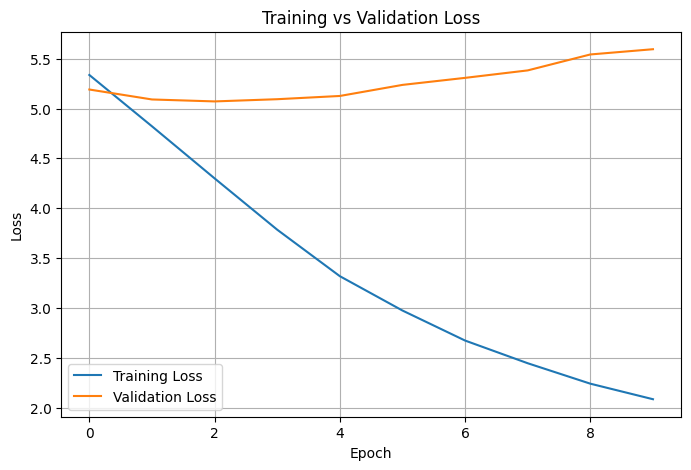

In [104]:
# ==========================================================
# TRAINING CURVES
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    validation_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()